In [1]:
# Importing libraries
import pandas as pd
import plotly.express as px
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.stats.diagnostic import acorr_ljungbox

# Load and Filter Data

In [2]:
# Loading the data
crude_data= pd.read_csv("/kaggle/input/datasets/iitm21f3001361/gjr-garch-volatility-forecasting/RWTCd.csv", index_col= None)
crude_data.head()

FileNotFoundError: [Errno 2] No such file or directory: '/kaggle/input/datasets/iitm21f3001361/gjr-garch-volatility-forecasting/RWTCd.csv'

In [ ]:
# Filtering the data
crude_data["Date"] = pd.to_datetime(crude_data["Date"])
crude_data = crude_data[crude_data["Date"] >= pd.Timestamp("2021-01-01")].reset_index(drop=True)
crude_data.head()


,Date,Price
0,2021-01-04,47.47
1,2021-01-05,49.78
2,2021-01-06,50.45
3,2021-01-07,50.63
4,2021-01-08,52.14


In [ ]:
# Calculating log returns
crude_data["Log Returns"]= np.log(crude_data["Price"] / crude_data["Price"].shift(1))
crude_data= crude_data.dropna()
crude_data.head()

,Date,Price,Log Returns
1,2021-01-05,49.78,0.047515
2,2021-01-06,50.45,0.013369
3,2021-01-07,50.63,0.003562
4,2021-01-08,52.14,0.029388
5,2021-01-11,52.15,0.000192


# Exploratory Data Analysis

In [ ]:
crude_data.size

3804

In [ ]:
crude_data.isna().sum()

Date           0
Price          0
Log Returns    0
dtype: int64

In [ ]:
crude_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1268 entries, 1 to 1268
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   Date         1268 non-null   datetime64[ns]
 1   Price        1268 non-null   float64       
 2   Log Returns  1268 non-null   float64       
dtypes: datetime64[ns](1), float64(2)
memory usage: 39.6 KB


In [ ]:
crude_data.describe()

,Date,Price,Log Returns
count,1268,1268.000000,1268.000000
mean,2023-07-16 15:31:13.817034752,76.301806,0.000205
min,2021-01-05 00:00:00,49.780000,-0.127771
25%,2022-04-07 18:00:00,67.740000,-0.012618
50%,2023-07-15 12:00:00,74.235000,0.001435
75%,2024-10-21 06:00:00,82.217500,0.014318
max,2026-02-02 00:00:00,123.640000,0.082141
std,NaN,13.114911,0.022688


In [ ]:
# Visualising the price over time
fig1= px.line(data_frame= crude_data, x= "Date", y= "Price", title= "Closing Price Data for Crude Oil")
fig1.show()


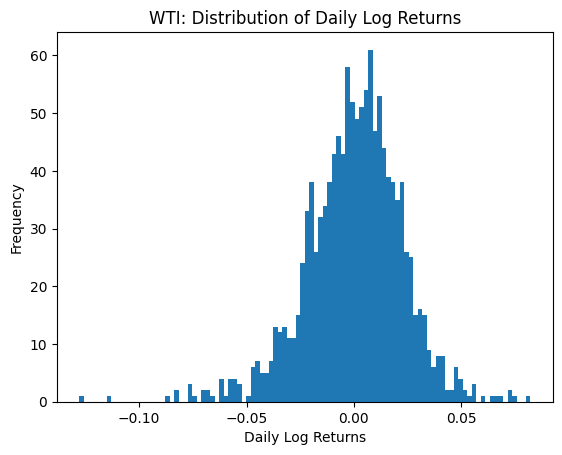

In [ ]:
# Visualising the distribution of daily log returns
plt.figure()
plt.hist(crude_data["Log Returns"].dropna(), bins=100)
plt.xlabel("Daily Log Returns")
plt.ylabel("Frequency")
plt.title("WTI: Distribution of Daily Log Returns")
plt.show()


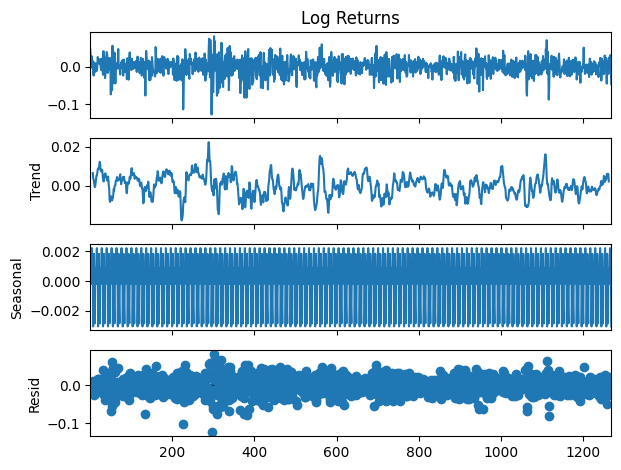

In [ ]:
decompose = seasonal_decompose(crude_data["Log Returns"], period=12).plot() #period: how many times calculated in a year (12=monthly, 4=quarterly, 1=annual)


* Trend does not exists - constant mean observed
* Seasonality (seasonal variations at regular time intervals) appears to exist


Text(0, 0.5, 'Returns')

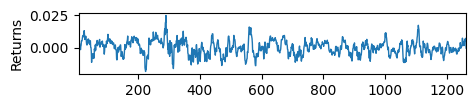

In [ ]:
plt.figure(figsize=(5, 0.8))
crude_data["Log Returns"].rolling(window=12, center=True).mean().plot(lw=1)
plt.margins(x=0)
plt.ylabel('Returns')

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# 1. Ensure Date is the index (crucial for x-axis labeling)
crude_data['Date'] = pd.to_datetime(crude_data['Date'])
crude_data.set_index('Date', inplace=True)

plt.figure(figsize=(5, 0.8))

# 2. Plot the rolling mean
ax = crude_data["Log Returns"].rolling(window=12, center=True).mean().plot(lw=1)

# 3. Format the x-axis to show only the Year
plt.margins(x=0)
plt.xticks(rotation=0)
ax.xaxis.set_major_locator(ticker.MaxNLocator(2)) # Limit to 2 ticks as requested
plt.tick_params(axis='x', labelsize=6)

# 4. Remove all whitespace
plt.tight_layout(pad=0)
plt.subplots_adjust(left=0.1, right=1, top=1, bottom=0.2) # Adjusted for label visibility

plt.show()

# Stationarity Testing

In [ ]:
def adf_test(timeseries):
    print("Results of Dickey-Fuller Test:")
    dftest = adfuller(timeseries, autolag="AIC")
    dfoutput = pd.Series(
        dftest[0:4],
        index=[
            "Test Statistic",
            "p-value",
            "#Lags Used",
            "Number of Observations Used",
        ],
    )
    for key, value in dftest[4].items():
        dfoutput["Critical Value (%s)" % key] = value
    print(dfoutput)


* Null Hypothesis: Series is non-stationary.
* Alternative Hypothesis: Series is stationary.


In [ ]:
series = crude_data["Log Returns"]
output = adf_test(series)


* Result of test: P-value is less than significance level of 0.05.
* Interpretation of Result: There is sufficient evidence to reject the null hypothesis. Hence, series is stationary and can be used for GARCH modeling.


# Ljung-Box Test

* Null Hypothesis: Series is white noise (no volatility clustering).
* Alternative Hypothesis: Series is not white noise (volatility clustering exists).

In [ ]:
squared_returns = series**2 # using squared_return to check variance dependence i.e. if a big shock today leads to a big shock tomorrow
lb_results = acorr_ljungbox(squared_returns, lags=[10, 15, 20, 100], return_df=True) # testing up to 10 lags to see short-to-medium term persistence
lb_results

* Result: P-values for autocorrelation for 10, 15, 20 as well as 100 lags is less than the significance level of 0.05.
* Interpretation: There is enough evidence to reject the null hypothesis. Hence, volatility clustering exists and should be modeled using a GARCH family model.
* Suggestion: Since patterns exist at 100th lag, a more complex model such as FIGARCH might be better suited.